This notebook is a follow-up of `registration-2d-SCIKITSH-v3.ipynb`. It aims to demonstrate two techniques:
- **symmetrization**: to make the transformation invariant by rotation, we add central symmetrics of the reference points (vessel) 
- **layerization**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
import os
os.environ["JAXTYPING_DISABLE"] = "1"
import torch
import skshapes as sks
from matplotlib.path import Path

%load_ext autoreload
%autoreload 2
import func as f

[KeOps] Compiling cuda jit compiler engine ... OK
[pyKeOps] Compiling nvrtc binder for python ... OK


# Data

In [2]:
# DEFINITION DES PARAMETRES DES OBJETS JOUET
# Tumeur
centre_tumeur = np.array([3.0, 2.0])
rayon_tumeur = 1.5

# Zone d'ablation
marge = 1.0  # 1 cm
rayon_ablation = rayon_tumeur + marge

# Paramètres de la rétractation (ground truth)
FORCE_RETRACTATION = 1 # Assez fort pour être visible
RAYON_INFLUENCE = rayon_ablation # Assez large pour toucher les vaisseaux

# CREATION DES OBJETS JOUET (PRE-OP)
# Foie
foie_pre = f.get_liver_shape()

# Tumeur
tumeur_pre = f.get_circle(centre_tumeur, rayon_tumeur)

# Zone d'Ablation (ground truth)
zone_ablation_pre = f.get_circle(centre_tumeur, rayon_ablation)

# --- NOUVEAUX PARAMÈTRES ---
NOMBRE_ARCS = 3          # On passe à 30 arcs
ANGLE_OUVERTURE = 22.5    # Arcs plus petits (22.5 degrés)
DIST_MAX_DU_CENTRE = 5  # J'ai légèrement augmenté pour bien remplir tout le foie

# On récupère le contour pour les tests (au cas où ce n'est pas déjà fait)
path_foie = Path(foie_pre)

vaisseaux_pre_3 = []

# --- BOUCLE DE GÉNÉRATION ---
compteur_securite = 0
while len(vaisseaux_pre_3) < NOMBRE_ARCS and compteur_securite < 2000:
    compteur_securite += 1
    
    # 1. Tirage aléatoire
    # Rayon : Toujours hors de la zone d'ablation (+1 marge), jusqu'au bord
    r_alea = np.random.uniform(rayon_ablation + 1, DIST_MAX_DU_CENTRE)
    
    # Angle
    angle_start_alea = np.random.uniform(0, 360)
    angle_end_alea = angle_start_alea + ANGLE_OUVERTURE
    
    # 2. Création de l'arc candidat
    arc_candidat = f.get_arc_vessel(
        centre_tumeur, 
        radius_vessel=r_alea, 
        start_angle=angle_start_alea, 
        end_angle=angle_end_alea
    )
    
    # 3. Vérification : Dedans ou Dehors ?
    is_inside = path_foie.contains_points(arc_candidat)
    
    # On garde seulement si TOUT l'arc est dans le foie
    if np.all(is_inside):
        vaisseaux_pre_3.append(arc_candidat)

# SIMULATION DE L'INTERVENTION (POST-OP)
# On applique ta fonction apply_retraction à TOUT le monde
foie_post = f.apply_retraction(foie_pre, centre_tumeur, strength=FORCE_RETRACTATION, radius_influence=RAYON_INFLUENCE)

# Note: La tumeur n'existe plus physiquement, mais on calcule la déformation de l'espace
# La zone d'ablation visible est la version rétractée de la zone théorique
zone_ablation_post = f.apply_retraction(zone_ablation_pre, centre_tumeur, strength=FORCE_RETRACTATION, radius_influence=RAYON_INFLUENCE)

# --- SIMULATION POST-OP ---
vaisseaux_post_3 = []
for segment in vaisseaux_pre_3:
    seg_post = f.apply_retraction(segment, centre_tumeur, strength=FORCE_RETRACTATION, radius_influence=RAYON_INFLUENCE)
    vaisseaux_post_3.append(seg_post)

In [3]:
# CRÉATION DES COMPOSANTS DE BASE
# On utilise les variables générées dans l'étape précédente :
# foie_pre, foie_post, vaisseaux_pre, vaisseaux_post, zone_ablation_pre, zone_ablation_post

# -- PRE-OP --
mesh_foie_pre = f.curve_to_polydata(foie_pre, is_closed=True)
mesh_vaisseaux_pre_3 = f.merge_vessels(vaisseaux_pre_3)
mesh_ablation_pre = f.curve_to_polydata(zone_ablation_pre, is_closed=True)

# -- POST-OP --
mesh_foie_post = f.curve_to_polydata(foie_post, is_closed=True)
mesh_vaisseaux_post_3 = f.merge_vessels(vaisseaux_post_3)
mesh_ablation_post = f.curve_to_polydata(zone_ablation_post, is_closed=True)


# ASSEMBLAGE DES STRUCTURES COMPLÈTES

# Structures registration SOURCE (Pre-Op : Foie + Vaisseaux)
structure_3_pre_reg = mesh_foie_pre + mesh_vaisseaux_pre_3

# Structures registration TARGET (Post-Op : Foie + Vaisseaux)
structure_3_post_reg = mesh_foie_post + mesh_vaisseaux_post_3

# Structure validation SOURCE (Pre-Op : Foie + Vaisseaux + Ablation)
# Celle-ci sert de "Vérité Terrain" complète
structure_pre_full = mesh_foie_pre + mesh_ablation_pre

# Structure validation TARGET (Post-Op : Foie + Vaisseaux + Ablation)
# Celle-ci sert à vérifier visuellement la rétractation avant correction
structure_post_full = mesh_foie_post + mesh_ablation_post

# Baseline

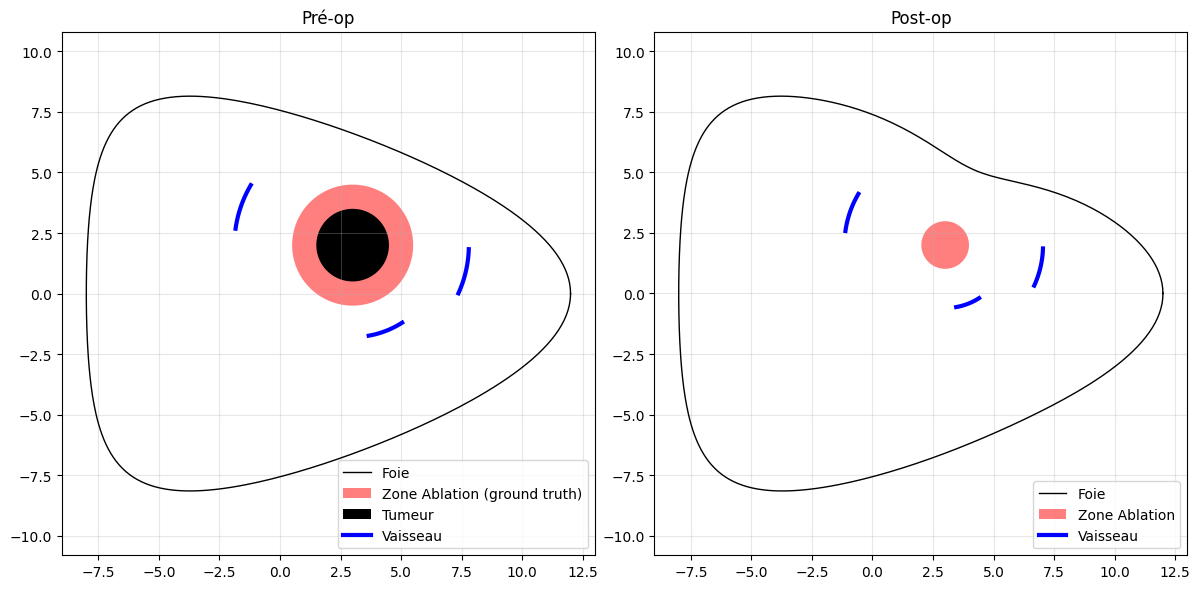

In [4]:
f.visualiser_intervention(
    foie_pre, 
    zone_ablation_pre, 
    tumeur_pre, 
    vaisseaux_pre_3,  # Votre liste spécifique de vaisseaux
    foie_post, 
    zone_ablation_post, 
    vaisseaux_post_3
)

Nombre de points de contrôle : 625
Début du recalage Haute Définition...


[KeOps] Generating code for Sum_Reduction reduction (with parameters 0) of formula Exp(-Sum((a-b)**2))*c with a=Var(0,2,0), b=Var(1,2,1), c=Var(2,2,1) ... OK
[KeOps] Generating code for Sum_Reduction reduction (with parameters 0) of formula (-2*((a-b)*(d|c)))*Exp(-Sum((a-b)**2)) with a=Var(0,2,0), b=Var(1,2,1), c=Var(2,2,1), d=Var(3,2,0) ... OK
[KeOps] Generating code for Sum_Reduction reduction (with parameters 1) of formula (2*((a-b)*(d|c)))*Exp(-Sum((a-b)**2)) with a=Var(0,2,0), b=Var(1,2,1), c=Var(2,2,1), d=Var(3,2,0) ... OK
[KeOps] Generating code for Sum_Reduction reduction (with parameters 1) of formula Exp(-Sum((a-b)**2))*d with a=Var(0,2,0), b=Var(1,2,1), d=Var(3,2,0) ... OK
Initial loss : 5.54e-02
  = 5.54e-02 + 0.001 * 0.00e+00 (fidelity + regularization_weight * regularization)
[KeOps] Generating code for Sum_Reduction reduction (with parameters 0) of formula (-2*((a-b)*(f|d)))*Exp(-Sum((a-b)**2)) with a=Var(0,2,0), b=Var(1,2,1), d=Var(3,2,0), f=Var(5,2,1) ... OK
[KeOps] Ge

2026-02-04 19:23:10.305 (  32.958s) [    7800BBB6E740]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


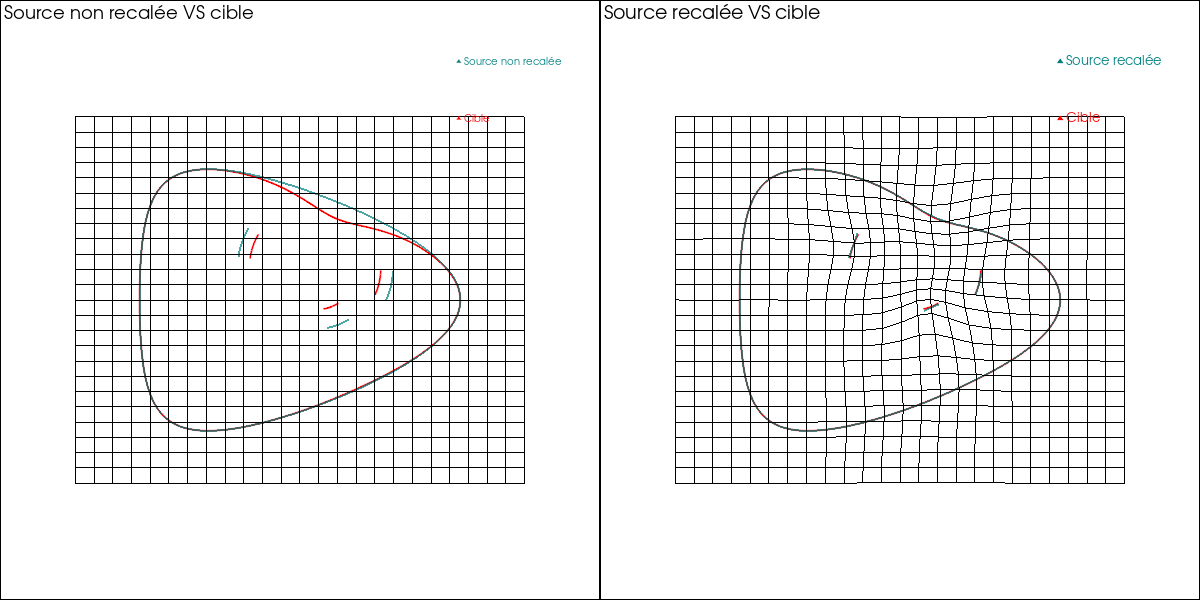

In [5]:
# 1. CHARGEMENT
source = sks.PolyData(structure_3_pre_reg)
target = sks.PolyData(structure_3_post_reg)

# =========================================================
# 2. DEFINITION DE LA GRILLE FINE (REFINE)
# =========================================================

# N=25 : On passe d'une grille grossière (10x10) à une grille fine (~25x25)
# offset=0.2 : On serre la grille au maximum autour de l'objet (marge minuscule)
source.control_points = source.bounding_grid(N=25, offset=0.2)

# =========================================================
# 3. MODÈLE ADAPTÉ (Fine Scale)
# =========================================================

model = sks.ExtrinsicDeformation(
    n_steps=10,
    kernel="gaussian",
    # IMPORTANT : Comme les points sont plus rapprochés, on réduit le scale.
    # Scale doit être environ 1.5x à 2x l'écartement des points de la grille.
    scale=1.5, 
    control_points=True
)

loss = sks.OptimalTransportLoss()

registration = sks.Registration(
    model=model,
    loss=loss,
    optimizer=sks.LBFGS(),
    n_iter=5, # On augmente un peu les itérations car il y a plus de paramètres à régler
    verbose=True,
    regularization_weight=0.001 
)

print(f"Nombre de points de contrôle : {source.control_points.n_points}")
print("Début du recalage Haute Définition...")
morphed = registration.fit_transform(source=source, target=target)
print("Terminé !")

f.visualiser_zoom_grid(source, target, morphed)

# Symmetrization

In [32]:
import numpy as np
import pyvista as pv
import skshapes as sks

def generate_symmetrized_vessels(vessel, center, n_rotations=3, liver: np.ndarray =None):
    """
    Duplique le vaisseau par rotation autour du centre pour simuler 
    des contraintes radiales partout dans le volume.
    """
        
    symmetrized_vessels = []
    
    # Vecteurs aléatoires ou réguliers pour l'axe de rotation
    angles = np.linspace(0, 2*np.pi, n_rotations) # ex: 0, 120, 240
    
    for angle in angles:
        # 1. Centrer les points
        pts = vessel - center
        
        # 2. Rotation (Ici autour de l'axe Z pour l'exemple, mais on peut varier)
        # En 3D pure, l'idéal est une symétrie centrale : p_new = -p_old
        # Mais une rotation permet de garder la structure du tube.
        rotation_matrix = np.array([
            [np.cos(angle), -np.sin(angle)],
            [np.sin(angle),  np.cos(angle)]
        ])
        
        # 3. Recentrer
        pts_rotated = np.dot(pts, rotation_matrix.T)
        if liver is not None:
            # Vérification que les points restent dans le foie
            path_liver = Path(liver)
            is_inside_liver = path_liver.contains_points(pts_rotated + center)
            if not np.all(is_inside_liver):
                continue
            

        symmetrized_vessels.append(pts_rotated + center)
        
        
    return symmetrized_vessels

# --- UTILISATION ---

# 1. On génère les fantômes pour la SOURCE (Pre-Op)
vessels_pre_symmetrized = np.concatenate([generate_symmetrized_vessels(vaisseau, centre_tumeur, n_rotations=8, liver=foie_pre) for vaisseau in vaisseaux_pre_3])

# 2. On génère les fantômes pour la CIBLE (Post-Op)
# IMPORTANT : On applique exactement les mêmes rotations au vaisseau CIBLE.
# Ainsi, si le vrai vaisseau s'est rapproché de 1cm, le fantôme se rapprochera de 1cm.
vessels_post_symmetrized = np.concatenate([generate_symmetrized_vessels(vaisseau, centre_tumeur, n_rotations=8, liver=foie_post) for vaisseau in vaisseaux_post_3])



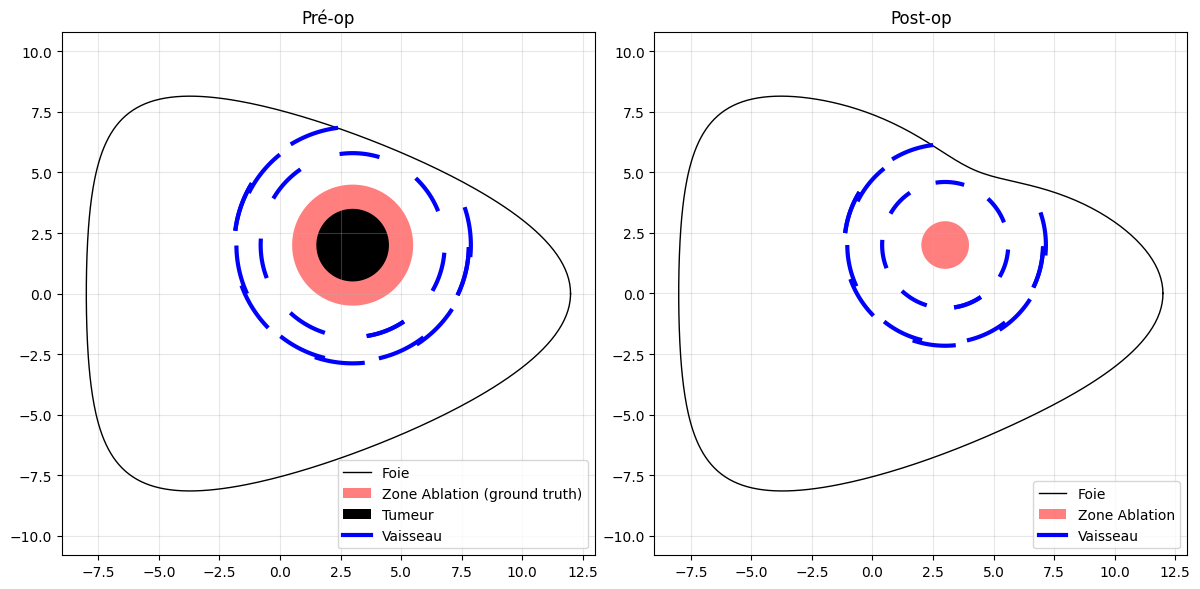

In [33]:
f.visualiser_intervention(
    foie_pre, 
    zone_ablation_pre, 
    tumeur_pre, 
    vessels_pre_symmetrized,  # Votre liste spécifique de vaisseaux
    foie_post,
    zone_ablation_post,
    vessels_post_symmetrized  # Votre liste spécifique de vaisseaux
)

In [34]:
structure_3_pre_reg_sym = f.curve_to_polydata(foie_pre, is_closed=True) + f.merge_vessels(vessels_pre_symmetrized)
structure_3_post_reg_sym = f.curve_to_polydata(foie_post, is_closed=True) + f.merge_vessels(vessels_post_symmetrized)

Nombre de points de contrôle : 625
Début du recalage Haute Définition...
Initial loss : 1.80e-01
  = 1.80e-01 + 0.001 * 0.00e+00 (fidelity + regularization_weight * regularization)
Loss after 1 iteration(s) : 4.38e-03
  = 3.61e-04 + 0.001 * 4.02e+00 (fidelity + regularization_weight * regularization)
Loss after 2 iteration(s) : 4.14e-03
  = 2.75e-04 + 0.001 * 3.87e+00 (fidelity + regularization_weight * regularization)
Loss after 3 iteration(s) : 4.08e-03
  = 2.33e-04 + 0.001 * 3.85e+00 (fidelity + regularization_weight * regularization)
Loss after 4 iteration(s) : 4.07e-03
  = 2.18e-04 + 0.001 * 3.85e+00 (fidelity + regularization_weight * regularization)
Loss after 5 iteration(s) : 4.07e-03
  = 2.17e-04 + 0.001 * 3.85e+00 (fidelity + regularization_weight * regularization)
Terminé !


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


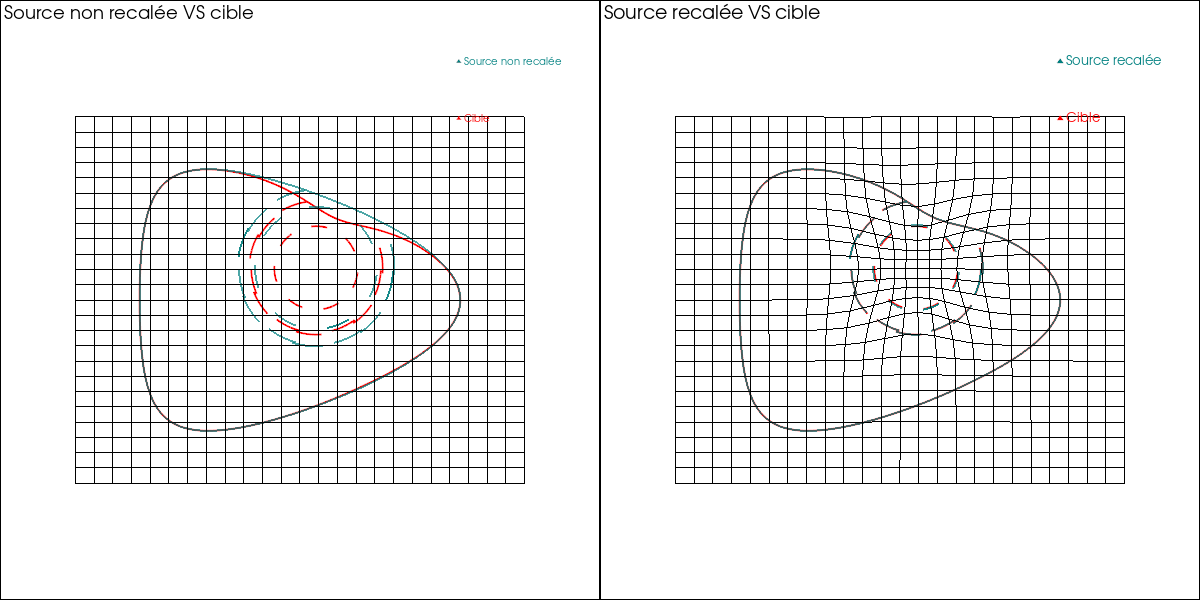

In [35]:
# 1. CHARGEMENT
source = sks.PolyData(structure_3_pre_reg_sym)
target = sks.PolyData(structure_3_post_reg_sym)

# =========================================================
# 2. DEFINITION DE LA GRILLE FINE (REFINE)
# =========================================================

# N=25 : On passe d'une grille grossière (10x10) à une grille fine (~25x25)
# offset=0.2 : On serre la grille au maximum autour de l'objet (marge minuscule)
source.control_points = source.bounding_grid(N=25, offset=0.2)

# =========================================================
# 3. MODÈLE ADAPTÉ (Fine Scale)
# =========================================================

model = sks.ExtrinsicDeformation(
    n_steps=10,
    kernel="gaussian",
    # IMPORTANT : Comme les points sont plus rapprochés, on réduit le scale.
    # Scale doit être environ 1.5x à 2x l'écartement des points de la grille.
    scale=1.5, 
    control_points=True
)

loss = sks.OptimalTransportLoss()

registration = sks.Registration(
    model=model,
    loss=loss,
    optimizer=sks.LBFGS(),
    n_iter=5, # On augmente un peu les itérations car il y a plus de paramètres à régler
    verbose=True,
    regularization_weight=0.001 
)

print(f"Nombre de points de contrôle : {source.control_points.n_points}")
print("Début du recalage Haute Définition...")
morphed = registration.fit_transform(source=source, target=target)
print("Terminé !")

f.visualiser_zoom_grid(source, target, morphed)